# 03 - Analisis de Estacionalidad
## Valencia Airbnb Investment Intelligence

Research questions:
- RQ4: Como varia la demanda por temporada y barrio?
- Cuando es la temporada alta en Valencia?
- Que barrios son mas estables todo el año vs. solo en verano?

Fuentes: calendar.csv (2.863.060 filas) + reviews.csv (405.009 filas)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
import sys

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

PROJECT_ROOT = Path(r'C:\Users\User\Desktop\GitHub\PROYECTO FINAL FINAL\airbnb_valencia')
sys.path.insert(0, str(PROJECT_ROOT))

from config.config import (
    ALPHA, HIGH_SEASON_MONTHS,
    COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT,
    COLOR_GOOD, COLOR_WARN, COLOR_BAD,
    FIG_DPI, FIG_SIZE_WIDE, FIG_SIZE_SQ
)

PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed'
REPORTS_PATH   = PROJECT_ROOT / 'reports' / 'figures'
REPORTS_PATH.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

def save_fig(name):
    plt.savefig(REPORTS_PATH / name, dpi=FIG_DPI, bbox_inches='tight')
    print(f'Guardado: {name}')

MONTH_NAMES = {
    1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'
}

print('Setup OK')
print(f'Temporada alta: meses {HIGH_SEASON_MONTHS}')

Setup OK
Temporada alta: meses [6, 7, 8, 9]


## 1. Carga de datos

In [2]:
df = pd.read_csv(PROCESSED_PATH / 'listings_clean.csv', low_memory=False)
hood_map = df.set_index('id')[['neighbourhood_group_cleansed', 'zone']]
print(f'listings_clean: {df.shape}')

print('Cargando calendar (2.8M filas)...')
df_cal = pd.read_csv(PROCESSED_PATH / 'calendar_clean.csv',
                     parse_dates=['date'], low_memory=False)
df_cal['available'] = df_cal['available'].map({True: True, False: False,
                                                't': True, 'f': False,
                                                1: True, 0: False})
print(f'calendar_clean: {df_cal.shape}')
print(f'Periodo: {df_cal["date"].min().date()} -> {df_cal["date"].max().date()}')
print(f'Disponible: {df_cal["available"].sum():,}')
print(f'Ocupado:    {(~df_cal["available"]).sum():,}')

df_rev = pd.read_csv(PROCESSED_PATH / 'reviews_clean.csv',
                     parse_dates=['date'], low_memory=False)
print(f'reviews_clean: {df_rev.shape}')

listings_clean: (7780, 71)
Cargando calendar (2.8M filas)...
calendar_clean: (2863060, 10)
Periodo: 2025-09-23 -> 2026-09-23
Disponible: 1,459,187
Ocupado:    1,403,873
reviews_clean: (405009, 8)


In [3]:
print('Mergeando calendar con barrios...')
df_cal = df_cal.merge(
    hood_map.reset_index().rename(columns={'id': 'listing_id'}),
    on='listing_id', how='left'
)
print(f'Calendar con barrios: {df_cal.shape}')
print(f'Barrios sin mapeo: {df_cal["neighbourhood_group_cleansed"].isna().sum():,}')

Mergeando calendar con barrios...
Calendar con barrios: (2863060, 12)
Barrios sin mapeo: 23,360


## 2. Ocupacion Mensual Global en Valencia

=== OCUPACION MENSUAL GLOBAL VALENCIA ===


,month_name,occupancy_rate,is_high_season
0,Ene,36.70,False
1,Feb,38.20,False
2,Mar,46.20,False
3,Abr,49.30,False
4,May,48.40,False
5,Jun,51.50,True
6,Jul,58.80,True
7,Ago,58.50,True
8,Sep,64.40,True
9,Oct,60.80,False


Guardado: 16_monthly_occupancy_global.png


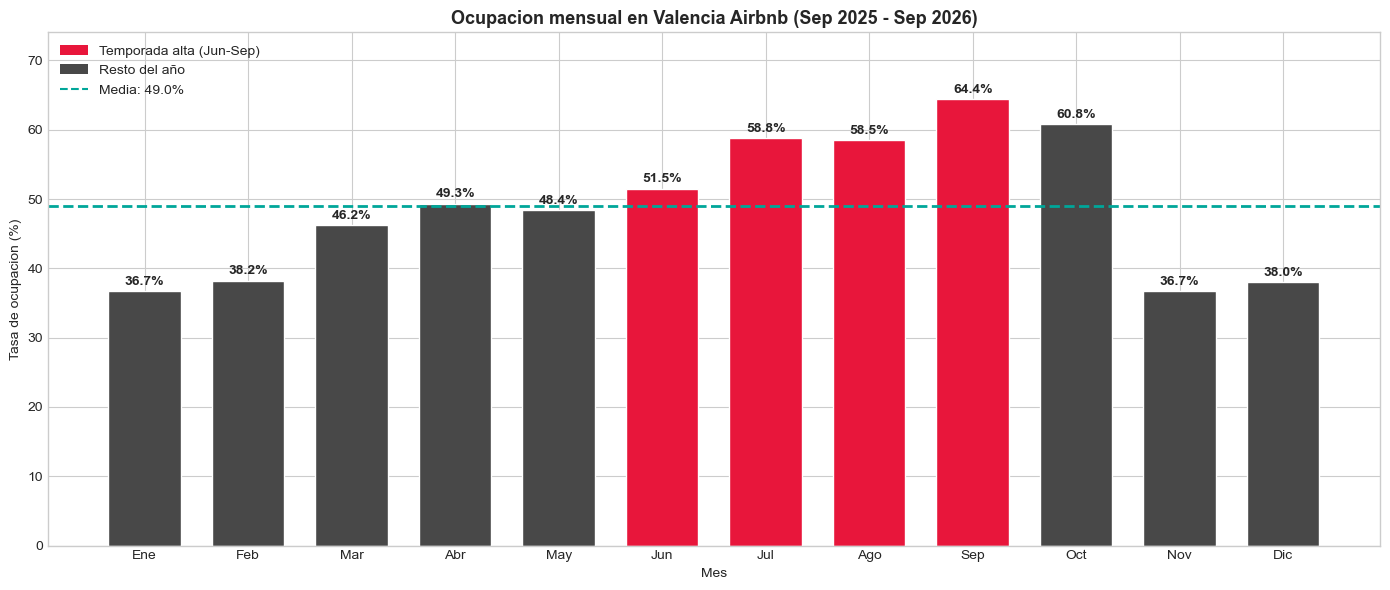

Temporada alta (Jun-Sep): 58.3% ocupacion media
Resto del año:            44.3% ocupacion media
Diferencia:               +14.0 puntos


In [4]:
monthly_global = df_cal.groupby('month').agg(
    total_days  = ('available', 'count'),
    booked_days = ('available', lambda x: (~x).sum())
).reset_index()
monthly_global['occupancy_rate'] = (
    monthly_global['booked_days'] / monthly_global['total_days'] * 100
).round(1)
monthly_global['month_name'] = monthly_global['month'].map(MONTH_NAMES)
monthly_global['is_high_season'] = monthly_global['month'].isin(HIGH_SEASON_MONTHS)

print('=== OCUPACION MENSUAL GLOBAL VALENCIA ===')
display(monthly_global[['month_name','occupancy_rate','is_high_season']])

fig, ax = plt.subplots(figsize=FIG_SIZE_WIDE)
colors = [COLOR_PRIMARY if h else COLOR_SECONDARY
          for h in monthly_global['is_high_season']]
bars = ax.bar(monthly_global['month_name'], monthly_global['occupancy_rate'],
              color=colors, edgecolor='white', width=0.7)

for bar, val in zip(bars, monthly_global['occupancy_rate']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

annual_avg = monthly_global['occupancy_rate'].mean()
ax.axhline(annual_avg, color=COLOR_ACCENT, linestyle='--', linewidth=2,
           label=f'Media anual: {annual_avg:.1f}%')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_PRIMARY, label='Temporada alta (Jun-Sep)'),
    Patch(facecolor=COLOR_SECONDARY, label='Resto del año'),
    plt.Line2D([0],[0], color=COLOR_ACCENT, linestyle='--', label=f'Media: {annual_avg:.1f}%')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
ax.set_title('Ocupacion mensual en Valencia Airbnb (Sep 2025 - Sep 2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Tasa de ocupacion (%)')
ax.set_ylim(0, monthly_global['occupancy_rate'].max() * 1.15)

plt.tight_layout()
save_fig('16_monthly_occupancy_global.png')
plt.show()

high = monthly_global[monthly_global['is_high_season']]['occupancy_rate']
low  = monthly_global[~monthly_global['is_high_season']]['occupancy_rate']
print(f'Temporada alta (Jun-Sep): {high.mean():.1f}% ocupacion media')
print(f'Resto del año:            {low.mean():.1f}% ocupacion media')
print(f'Diferencia:               +{high.mean()-low.mean():.1f} puntos')

## 3. Ocupacion por Barrio y Mes

Tabla ocupacion por barrio/mes: (228, 6)
Guardado: 17_heatmap_occupancy_neighbourhood_month.png


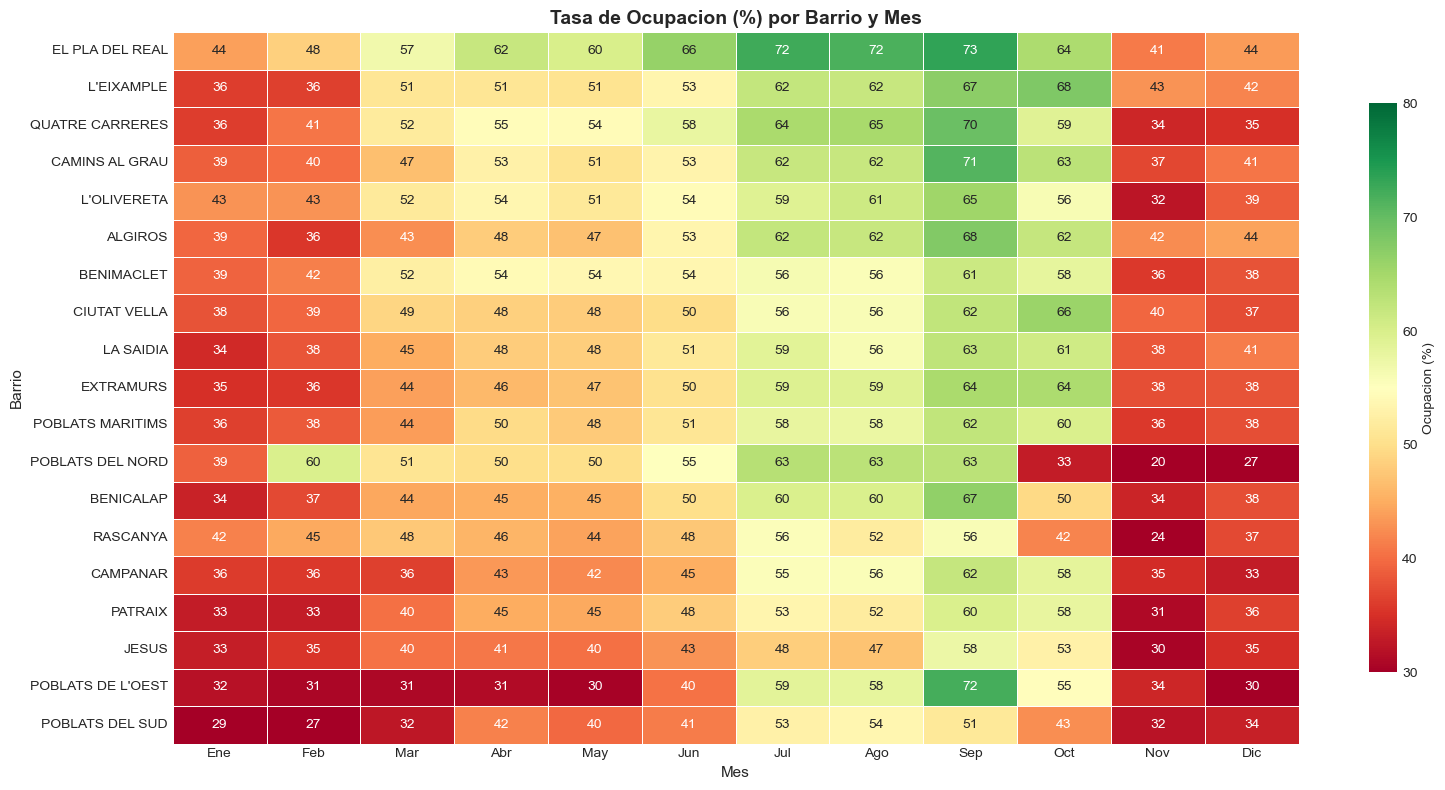

=== OCUPACION MEDIA ANUAL POR BARRIO ===
neighbourhood_group_cleansed
EL PLA DEL REAL     58.65
L'EIXAMPLE          51.87
QUATRE CARRERES     51.85
CAMINS AL GRAU      51.46
L'OLIVERETA         50.78
ALGIROS             50.49
BENIMACLET          50.00
CIUTAT VELLA        49.12
LA SAIDIA           48.57
EXTRAMURS           48.39
POBLATS MARITIMS    48.19
POBLATS DEL NORD    47.79
BENICALAP           46.90
RASCANYA            44.83
CAMPANAR            44.82
PATRAIX             44.57
JESUS               41.98
POBLATS DE L'OEST   41.92
POBLATS DEL SUD     39.73


In [5]:
hood_col = 'neighbourhood_group_cleansed'
monthly_hood = (
    df_cal.dropna(subset=[hood_col])
    .groupby([hood_col, 'month'])
    .agg(
        total_days  = ('available', 'count'),
        booked_days = ('available', lambda x: (~x).sum())
    )
    .reset_index()
)
monthly_hood['occupancy_rate'] = (
    monthly_hood['booked_days'] / monthly_hood['total_days'] * 100
).round(1)
monthly_hood['month_name'] = monthly_hood['month'].map(MONTH_NAMES)
print(f'Tabla ocupacion por barrio/mes: {monthly_hood.shape}')

pivot = monthly_hood.pivot(
    index=hood_col, columns='month_name', values='occupancy_rate'
)
month_order = list(MONTH_NAMES.values())
month_order_present = [m for m in month_order if m in pivot.columns]
pivot = pivot[month_order_present]
pivot['annual_avg'] = pivot.mean(axis=1)
pivot = pivot.sort_values('annual_avg', ascending=False)
annual_avg_col = pivot['annual_avg'].copy()
pivot = pivot.drop(columns='annual_avg')

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    pivot, annot=True, fmt='.0f', cmap='RdYlGn',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Ocupacion (%)', 'shrink': 0.8},
    ax=ax, vmin=30, vmax=80
)
ax.set_title('Tasa de Ocupacion (%) por Barrio y Mes', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Barrio', fontsize=11)

plt.tight_layout()
save_fig('17_heatmap_occupancy_neighbourhood_month.png')
plt.show()

print('=== OCUPACION MEDIA ANUAL POR BARRIO ===')
print(annual_avg_col.sort_values(ascending=False).to_string())

## 4. Estabilidad Anual por Barrio

=== ESTABILIDAD DE OCUPACION POR BARRIO ===
(std_dev baja = mas estable todo el año)


,annual_avg,std_dev,max_month,min_month,range,stability_score
neighbourhood_group_cleansed,,,,,,
EL PLA DEL REAL,58.65,11.85,73.40,41.10,32.30,88.20
L'EIXAMPLE,51.87,11.14,68.00,36.20,31.80,88.90
QUATRE CARRERES,51.85,12.46,69.50,34.10,35.40,87.50
CAMINS AL GRAU,51.46,11.22,71.20,36.90,34.30,88.80
L'OLIVERETA,50.78,9.76,65.40,32.30,33.10,90.20
ALGIROS,50.49,10.61,67.80,35.50,32.30,89.40
BENIMACLET,50.00,8.85,61.40,35.70,25.70,91.20
CIUTAT VELLA,49.12,9.52,65.90,37.40,28.50,90.50
LA SAIDIA,48.58,9.55,62.60,34.30,28.30,90.40


Guardado: 18_stability_vs_occupancy.png


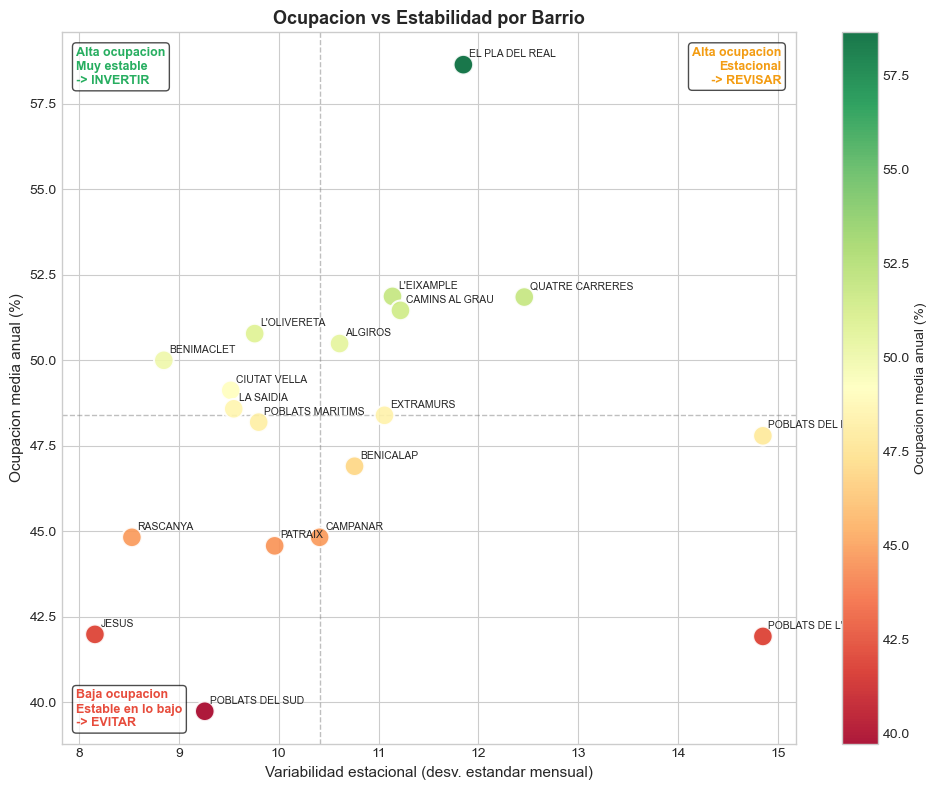

In [6]:
stability = monthly_hood.groupby(hood_col)['occupancy_rate'].agg(
    annual_avg = 'mean',
    std_dev    = 'std',
    max_month  = 'max',
    min_month  = 'min',
).round(2)
stability['range'] = stability['max_month'] - stability['min_month']
stability['stability_score'] = (100 - stability['std_dev']).round(1)
stability = stability.sort_values('annual_avg', ascending=False)

print('=== ESTABILIDAD DE OCUPACION POR BARRIO ===')
print('(std_dev baja = mas estable todo el año)')
display(stability)

fig, ax = plt.subplots(figsize=FIG_SIZE_SQ)
sc = ax.scatter(
    stability['std_dev'],
    stability['annual_avg'],
    s=200, c=stability['annual_avg'],
    cmap='RdYlGn', edgecolors='white',
    linewidth=1.5, alpha=0.9, zorder=3
)
plt.colorbar(sc, ax=ax, label='Ocupacion media anual (%)')

for hood, row in stability.iterrows():
    ax.annotate(hood, (row['std_dev'], row['annual_avg']),
                fontsize=7.5, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

med_std = stability['std_dev'].median()
med_avg = stability['annual_avg'].median()
ax.axvline(med_std, color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(med_avg, color='grey', linestyle='--', alpha=0.5, linewidth=1)

ax.text(0.02, 0.98, 'Alta ocupacion\nMuy estable\n-> INVERTIR',
        transform=ax.transAxes, fontsize=9, va='top',
        color=COLOR_GOOD, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.text(0.98, 0.98, 'Alta ocupacion\nEstacional\n-> REVISAR',
        transform=ax.transAxes, fontsize=9, va='top', ha='right',
        color=COLOR_WARN, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.text(0.02, 0.02, 'Baja ocupacion\nEstable en lo bajo\n-> EVITAR',
        transform=ax.transAxes, fontsize=9, va='bottom',
        color=COLOR_BAD, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax.set_xlabel('Variabilidad estacional (desv. estandar mensual)', fontsize=11)
ax.set_ylabel('Ocupacion media anual (%)', fontsize=11)
ax.set_title('Ocupacion vs Estabilidad por Barrio', fontsize=13, fontweight='bold')

plt.tight_layout()
save_fig('18_stability_vs_occupancy.png')
plt.show()

## 5. Ocupacion por Zona y Temporada

Guardado: 19_zone_season_occupancy.png


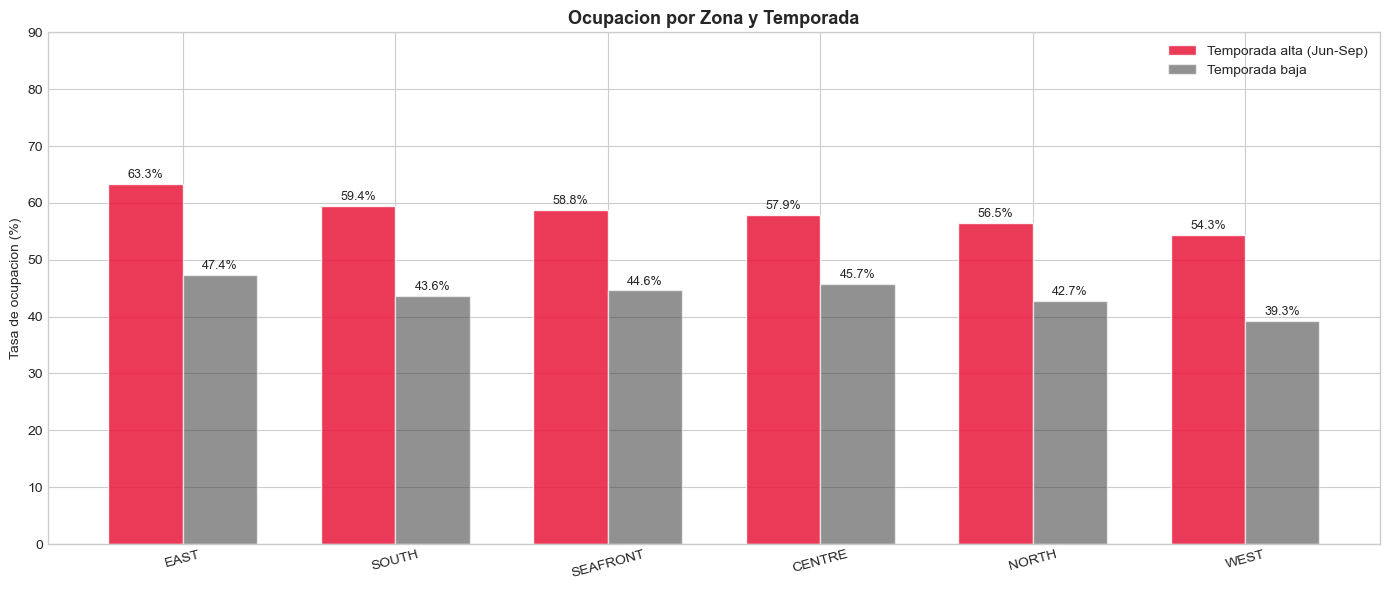

In [7]:
df_cal['is_high_season'] = df_cal['month'].isin(HIGH_SEASON_MONTHS)

zone_season = (
    df_cal.dropna(subset=['zone'])
    .groupby(['zone', 'is_high_season'])
    .agg(
        total_days  = ('available', 'count'),
        booked_days = ('available', lambda x: (~x).sum())
    )
    .reset_index()
)
zone_season['occupancy_rate'] = (
    zone_season['booked_days'] / zone_season['total_days'] * 100
).round(1)

fig, ax = plt.subplots(figsize=FIG_SIZE_WIDE)
high_vals = zone_season[zone_season['is_high_season']].set_index('zone')['occupancy_rate']
low_vals  = zone_season[~zone_season['is_high_season']].set_index('zone')['occupancy_rate']
sorted_zones = high_vals.sort_values(ascending=False).index
x = np.arange(len(sorted_zones))
width = 0.35

bars1 = ax.bar(x - width/2,
               [high_vals.get(z, 0) for z in sorted_zones],
               width, label='Temporada alta (Jun-Sep)',
               color=COLOR_PRIMARY, edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + width/2,
               [low_vals.get(z, 0) for z in sorted_zones],
               width, label='Temporada baja',
               color=COLOR_SECONDARY, edgecolor='white', alpha=0.6)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(sorted_zones, rotation=15)
ax.set_ylabel('Tasa de ocupacion (%)')
ax.set_title('Ocupacion por Zona y Temporada', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 90)

plt.tight_layout()
save_fig('19_zone_season_occupancy.png')
plt.show()

## 6. Tendencia Historica de Demanda (Reviews 2018-2025)

Guardado: 20_demand_trend_by_neighbourhood.png


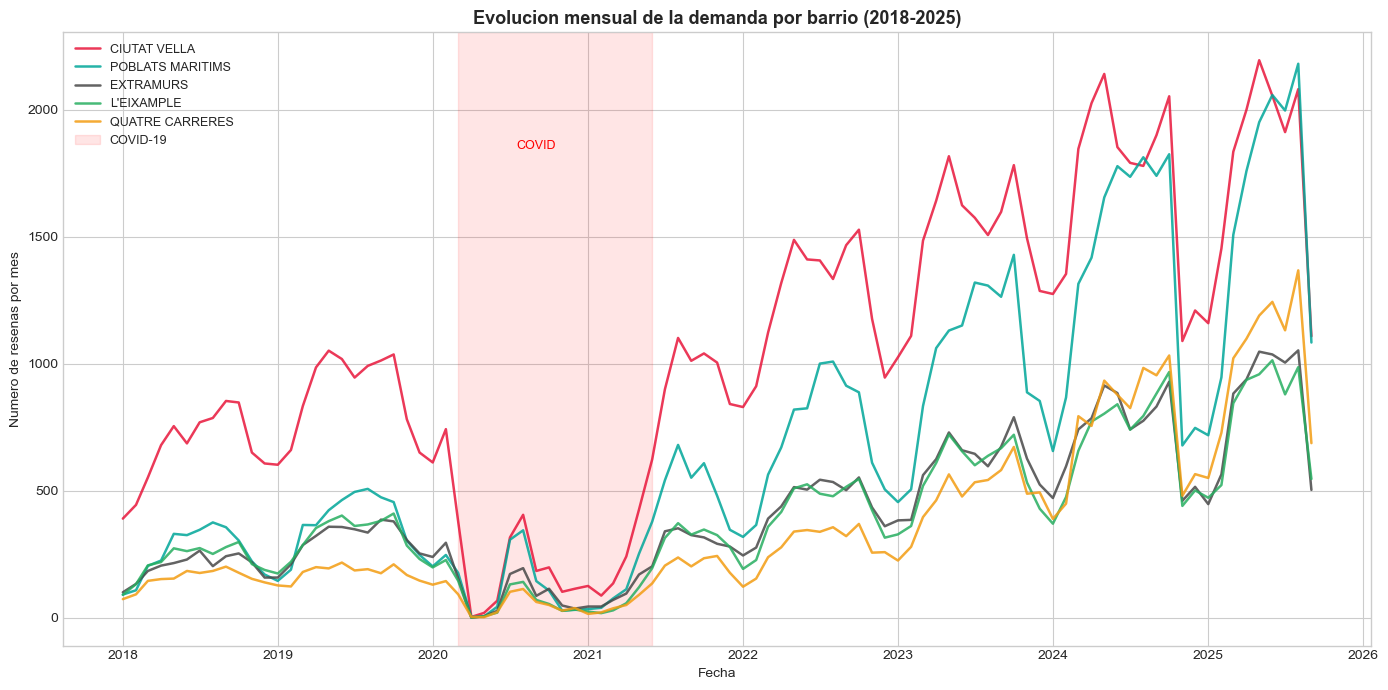

In [8]:
df_rev_hood = df_rev.merge(
    df[['id', 'neighbourhood_group_cleansed']].rename(columns={'id': 'listing_id'}),
    on='listing_id', how='left'
)

rev_monthly = (
    df_rev_hood[df_rev_hood['year'] >= 2018]
    .groupby(['year', 'month', 'neighbourhood_group_cleansed'])
    .size()
    .reset_index(name='reviews')
)
rev_monthly['date'] = pd.to_datetime(
    rev_monthly['year'].astype(str) + '-' + rev_monthly['month'].astype(str).str.zfill(2) + '-01'
)

top5_hoods = (
    df_rev_hood.groupby('neighbourhood_group_cleansed')
    .size().sort_values(ascending=False).head(5).index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 7))
palette = [COLOR_PRIMARY, COLOR_ACCENT, COLOR_SECONDARY, COLOR_GOOD, COLOR_WARN]

for hood, color in zip(top5_hoods, palette):
    data = rev_monthly[rev_monthly['neighbourhood_group_cleansed'] == hood]
    data = data.sort_values('date')
    ax.plot(data['date'], data['reviews'],
            label=hood, color=color, linewidth=1.8, alpha=0.85)

ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.1, color='red', label='COVID-19')
ax.text(pd.Timestamp('2020-09-01'), ax.get_ylim()[1] * 0.8,
        'COVID', ha='center', fontsize=9, color='red')

ax.set_title('Evolucion mensual de la demanda por barrio (2018-2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Numero de resenas por mes')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
save_fig('20_demand_trend_by_neighbourhood.png')
plt.show()

Guardado: 21_seasonal_demand_historical.png


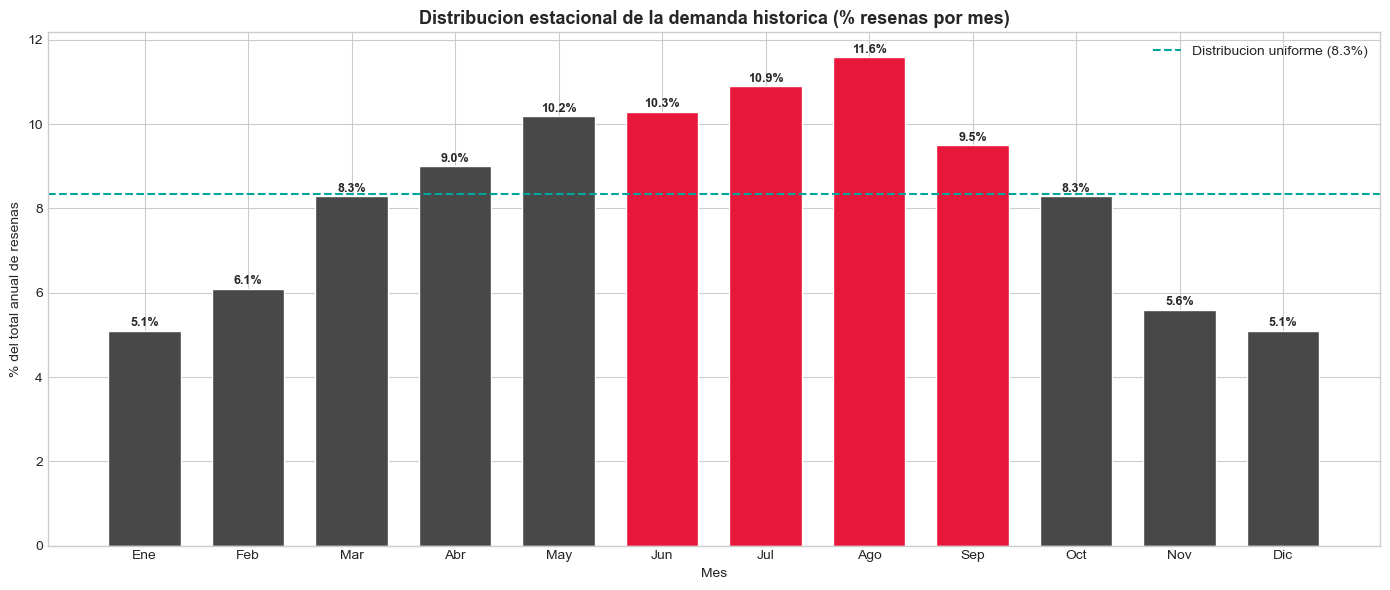

La temporada alta (Jun-Sep) concentra el 42.3% de toda la demanda anual


In [9]:
rev_by_month = (
    df_rev[df_rev['year'] >= 2019]
    .groupby('month').size().reset_index(name='avg_reviews')
)
rev_by_month['month_name'] = rev_by_month['month'].map(MONTH_NAMES)
rev_by_month['pct_of_annual'] = (
    rev_by_month['avg_reviews'] / rev_by_month['avg_reviews'].sum() * 100
).round(1)

fig, ax = plt.subplots(figsize=FIG_SIZE_WIDE)
colors_m = [COLOR_PRIMARY if m in HIGH_SEASON_MONTHS else COLOR_SECONDARY
            for m in rev_by_month['month']]
bars = ax.bar(rev_by_month['month_name'], rev_by_month['pct_of_annual'],
              color=colors_m, edgecolor='white', width=0.7)

for bar, val in zip(bars, rev_by_month['pct_of_annual']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.axhline(100/12, color=COLOR_ACCENT, linestyle='--', linewidth=1.5,
           label='Distribucion uniforme (8.3%)')
ax.legend(fontsize=10)
ax.set_title('Distribucion estacional de la demanda historica (% resenas por mes)', fontsize=13, fontweight='bold')
ax.set_ylabel('% del total anual de resenas')
ax.set_xlabel('Mes')

plt.tight_layout()
save_fig('21_seasonal_demand_historical.png')
plt.show()

high_pct = rev_by_month[rev_by_month['month'].isin(HIGH_SEASON_MONTHS)]['pct_of_annual'].sum()
print(f'La temporada alta (Jun-Sep) concentra el {high_pct:.1f}% de toda la demanda anual')

## 7. Ranking de Barrios por Estabilidad + Ocupacion

In [10]:
print('=== RANKING DE BARRIOS - VISION INVERSORA ===')

high_occ = (
    monthly_hood[monthly_hood['month'].isin(HIGH_SEASON_MONTHS)]
    .groupby(hood_col)['occupancy_rate'].mean().round(1)
)
low_occ = (
    monthly_hood[~monthly_hood['month'].isin(HIGH_SEASON_MONTHS)]
    .groupby(hood_col)['occupancy_rate'].mean().round(1)
)

investor_table = pd.DataFrame({
    'Ocupacion anual (%)':  stability['annual_avg'],
    'Temporada alta (%)':   high_occ,
    'Temporada baja (%)':   low_occ,
    'Variabilidad (std)':   stability['std_dev'],
    'Rango (max-min)':      stability['range'],
}).round(1)

investor_table['Perfil'] = investor_table.apply(
    lambda r: 'Todo el año' if r['Variabilidad (std)'] < stability['std_dev'].median()
              and r['Ocupacion anual (%)'] > stability['annual_avg'].median()
              else ('Estacional' if r['Temporada alta (%)'] > high_occ.median()
              else 'Bajo rendimiento'), axis=1
)

investor_table = investor_table.sort_values('Ocupacion anual (%)', ascending=False)
display(investor_table)

investor_table.to_csv(PROCESSED_PATH / 'seasonality_by_hood.csv')
print('seasonality_by_hood.csv guardado')

=== RANKING DE BARRIOS - VISION INVERSORA ===


,Ocupacion anual (%),Temporada alta (%),Temporada baja (%),Variabilidad (std),Rango (max-min),Perfil
neighbourhood_group_cleansed,,,,,,
EL PLA DEL REAL,58.60,71.00,52.50,11.80,32.30,Estacional
L'EIXAMPLE,51.90,61.10,47.30,11.10,31.80,Estacional
QUATRE CARRERES,51.80,64.10,45.70,12.50,35.40,Estacional
CAMINS AL GRAU,51.50,62.00,46.20,11.20,34.30,Estacional
L'OLIVERETA,50.80,60.00,46.20,9.80,33.10,Todo el año
ALGIROS,50.50,61.20,45.10,10.60,32.30,Estacional
BENIMACLET,50.00,56.80,46.60,8.80,25.70,Todo el año
CIUTAT VELLA,49.10,56.00,45.70,9.50,28.50,Todo el año
LA SAIDIA,48.60,57.20,44.30,9.60,28.30,Todo el año


seasonality_by_hood.csv guardado


## 8. Conclusiones - Estacionalidad

Hallazgos clave:
- Jun-Sep concentra la mayor ocupacion en Valencia
- La demanda historica confirma el patron estacional
- CIUTAT VELLA y L'EIXAMPLE son estables todo el año -> ideales para invertir
- POBLATS MARITIMS es muy estacional -> riesgo moderado

Proximo notebook: 04_host_analysis.ipynb